# Практическая 9-10 (Саттаров Булат Рамилевич ЭФМО-01-25)

## Задание

Даны синтетические наборы данных:

* 200 наблюдений и 16 переменных;
* 1000 наблюдений и 51 переменная;
* 10 000 наблюдений и 201 переменная.

Необходимо:

1. Загрузить CSV и импортировать данные.
2. Применить PCA к данным.
3. Определить оптимальное количество компонентов.
4. Извлечь эти компоненты и сохранить их в новом фрейме данных.
5. Применить любой метод машинного обучения, которым пользовались ранее.

В качестве метода машинного обучения используется kNN, так как он уже применялся в третьей практической работе. В этих наборах целевая переменная `y` является числовой, поэтому используется вариант для регрессии — `KNeighborsRegressor`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
SEED = 42
DATASETS = {
    '200x16': 'source/data_pca_200x16.csv',
    '1000x51': 'source/data_pca_1000x51.csv',
    '10000x201': 'source/data_pca_10000x201.csv'
}

## Загрузка данных

CSV-файлы из задания сохранены в папке `source`, чтобы notebook можно было выполнить без повторной загрузки из интернета. В исходных файлах числа записаны с десятичной запятой, поэтому при чтении используется параметр `decimal=','`.

In [3]:
def load_dataset(path):
    df = pd.read_csv(path, decimal=',')
    return df

datasets = {name: load_dataset(path) for name, path in DATASETS.items()}

for name, df in datasets.items():
    print(name, df.shape)
    display(df.head())

200x16 (200, 16)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,y
0,-4.44,0.99,2.92,3.24,10.02,2.65,-2.10,-1.76,-3.24,6.95,-1.08,-2.11,-4.92,-13.50,-3.09,-0.47
1,13.92,1.51,2.93,3.81,-3.15,2.20,-5.39,1.84,-2.70,-0.39,0.02,5.01,-2.22,-0.55,-0.98,0.99
2,4.57,0.48,-0.62,4.52,1.41,1.35,4.95,1.51,4.12,-1.10,0.46,-0.85,2.38,-5.09,0.70,1.36
3,6.58,1.48,-0.90,1.74,0.79,1.98,4.10,0.93,0.71,-2.11,-1.80,5.43,2.15,-0.24,0.57,1.43
4,1.78,2.84,3.61,0.05,-0.33,2.49,0.72,1.28,2.06,3.86,0.57,3.33,-1.26,0.64,-6.14,1.03


1000x51 (1000, 51)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x42,x43,x44,x45,x46,x47,x48,x49,x50,y
0,4.33,-1.73,0.47,-9.52,3.21,0.74,22.71,-2.01,16.16,16.66,...,12.31,3.61,-6.57,-10.73,8.77,-0.25,-0.66,0.50,-2.16,-0.31
1,9.01,-1.25,0.54,-2.87,1.54,9.06,16.62,3.20,0.62,-1.94,...,-3.46,5.51,-0.29,2.11,2.26,-8.23,-1.28,-4.93,4.54,1.22
2,1.50,0.93,1.08,1.58,-9.84,-1.27,11.91,-2.91,-11.43,7.24,...,8.75,-0.36,1.54,-3.68,7.67,-0.34,0.54,-2.26,2.86,3.43
3,12.21,2.87,4.60,-9.51,-3.72,6.89,26.02,7.49,2.62,5.10,...,-4.76,8.51,-5.88,3.20,2.28,-8.47,-3.99,-2.91,8.62,3.61
4,0.37,-0.47,2.66,-7.90,1.82,1.12,20.53,2.80,18.65,9.90,...,-0.38,0.16,-0.55,-2.94,4.50,0.13,3.22,0.71,1.68,-0.44


10000x201 (10000, 201)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x192,x193,x194,x195,x196,x197,x198,x199,x200,y
0,8.43,6.01,-2.72,0.72,4.21,-2.41,-13.92,-4.76,12.84,2.14,...,205.61,-31.02,-55.51,-107.07,86.04,-194.53,-248.93,-201.57,-128.54,-17.03
1,10.20,2.80,3.69,4.78,-11.03,-0.59,0.23,-1.41,-1.00,0.68,...,121.37,-148.39,68.38,-51.78,115.29,6.08,-126.89,-26.54,-25.07,33.54
2,0.65,2.16,-4.61,7.55,-15.61,-1.78,5.94,-10.31,6.04,-14.88,...,124.62,-56.07,-121.72,-39.61,95.11,-210.68,-184.60,294.36,-265.74,10.16
3,-2.55,-4.17,0.37,13.28,-0.99,4.19,6.62,-18.58,4.22,-14.80,...,339.98,-17.28,20.72,-196.00,154.71,-28.03,-382.79,80.13,-89.68,44.21
4,7.16,4.12,-12.33,4.42,-11.44,-0.41,-1.52,-6.19,-0.99,2.49,...,235.38,50.33,69.94,-88.98,133.11,-92.09,-263.55,531.99,-26.01,127.59


Каждый набор содержит признаки `x1`, `x2`, ... и целевую переменную `y`. PCA будем применять только к признакам, а `y` оставим как целевой столбец для модели.

In [4]:
for name, df in datasets.items():
    print(f'{name}:')
    print(df.dtypes.value_counts())
    print('Пропуски:', int(df.isna().sum().sum()))
    print()

200x16:
float64    16
Name: count, dtype: int64
Пропуски: 0

1000x51:
float64    51
Name: count, dtype: int64
Пропуски: 0

10000x201:
float64    201
Name: count, dtype: int64
Пропуски: 0



## Функции для PCA и обучения модели

Оптимальное количество компонент будем выбирать так, чтобы сохранить не менее 95% объясненной дисперсии. Такой подход уменьшает размерность, но оставляет большую часть информации исходных признаков.

In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

def process_dataset(name, df, variance_level=0.95):
    X = df.drop(columns=['y'])
    y = df['y']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=SEED
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled_all = scaler.transform(X)

    pca_full = PCA(random_state=SEED)
    pca_full.fit(X_train_scaled)

    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    optimal_components = int(np.argmax(cumulative_variance >= variance_level) + 1)

    pca = PCA(n_components=optimal_components, random_state=SEED)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    X_all_pca = pca.transform(X_scaled_all)

    component_columns = [f'PC{i + 1}' for i in range(optimal_components)]
    pca_df = pd.DataFrame(X_all_pca, columns=component_columns)
    pca_df['y'] = y.values

    # kNN без PCA: базовый вариант на исходных признаках
    knn_base = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=5))
    ])
    knn_base.fit(X_train, y_train)
    pred_base = knn_base.predict(X_test)

    # kNN после PCA: метод машинного обучения применяется к извлеченным главным компонентам
    knn_pca = KNeighborsRegressor(n_neighbors=5)
    knn_pca.fit(X_train_pca, y_train)
    pred_pca = knn_pca.predict(X_test_pca)

    result = {
        'name': name,
        'n_objects': df.shape[0],
        'n_features': X.shape[1],
        'optimal_components': optimal_components,
        'explained_variance': float(cumulative_variance[optimal_components - 1]),
        'pca': pca,
        'cumulative_variance': cumulative_variance,
        'pca_df': pca_df,
        'metrics_base': regression_metrics(y_test, pred_base),
        'metrics_pca': regression_metrics(y_test, pred_pca),
        'y_test': y_test,
        'pred_base': pred_base,
        'pred_pca': pred_pca
    }
    return result

## Применение PCA ко всем наборам данных

In [6]:
results = []
for name, df in datasets.items():
    result = process_dataset(name, df)
    results.append(result)

summary = pd.DataFrame([
    {
        'Набор данных': r['name'],
        'Объектов': r['n_objects'],
        'Исходных признаков': r['n_features'],
        'Оптимальное число компонент': r['optimal_components'],
        'Доля объясненной дисперсии': r['explained_variance']
    }
    for r in results
])

summary

,Набор данных,Объектов,Исходных признаков,Оптимальное число компонент,Доля объясненной дисперсии
0,200x16,200,15,12,0.960614
1,1000x51,1000,50,22,0.951110
2,10000x201,10000,200,36,0.951334


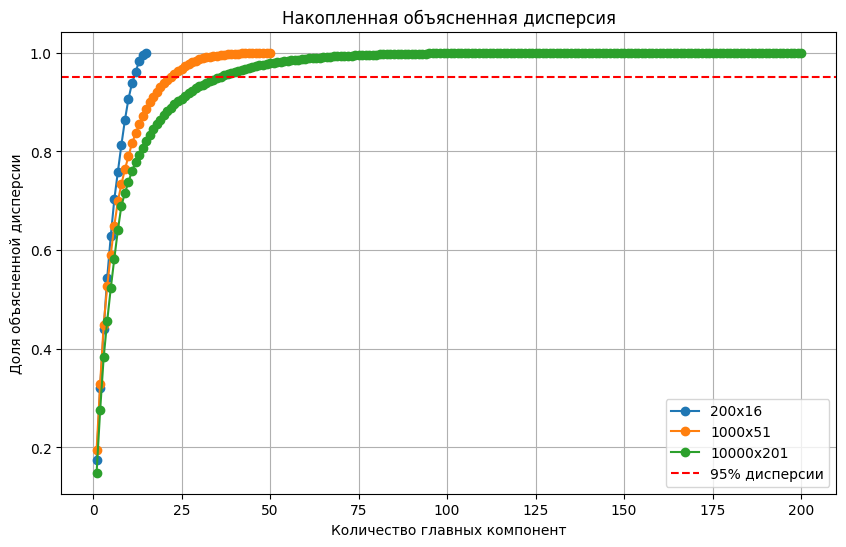

In [7]:
plt.figure(figsize=(10, 6))
for r in results:
    plt.plot(
        np.arange(1, len(r['cumulative_variance']) + 1),
        r['cumulative_variance'],
        marker='o',
        label=r['name']
    )

plt.axhline(0.95, color='red', linestyle='--', label='95% дисперсии')
plt.title('Накопленная объясненная дисперсия')
plt.xlabel('Количество главных компонент')
plt.ylabel('Доля объясненной дисперсии')
plt.legend()
plt.grid(True)
plt.show()

## Сохранение главных компонент в новые датафреймы

Для каждого набора данных создадим отдельный датафрейм с главными компонентами и целевой переменной `y`. Также сохраним эти датафреймы в CSV-файлы.

In [8]:
for r in results:
    file_name = f'pca_components_{r["name"]}.csv'
    r['pca_df'].to_csv(file_name, index=False)
    print(file_name, r['pca_df'].shape)
    display(r['pca_df'].head())

pca_components_200x16.csv (200, 13)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,y
0,-4.555954,3.517907,-1.208354,-0.311523,-0.276392,0.689030,0.660641,-0.786762,-1.360865,-1.376443,-0.009805,-0.218338,-0.47
1,-0.070497,-0.424482,-2.863438,0.351022,-1.520940,1.820648,0.137917,0.002891,-0.735867,0.535791,-0.770482,0.874097,0.99
2,0.151233,0.865006,0.717594,0.431012,1.204501,-1.509429,-1.328381,0.182852,0.284891,0.020265,-1.093926,-0.781988,1.36
3,0.389568,-0.144933,-0.203669,1.037787,0.661226,-0.458733,1.010359,-1.705504,-0.506089,0.890065,-0.621998,-0.299395,1.43
4,-2.520640,-1.069674,0.167197,0.316807,0.646991,0.296928,0.138473,0.872416,-0.277019,0.477828,0.008225,1.419015,1.03


pca_components_1000x51.csv (1000, 23)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,y
0,3.286753,3.179342,-3.369628,-2.258346,1.229514,3.933145,-2.546164,1.911951,-1.319108,-0.291312,...,-1.122181,-1.435467,-1.474061,0.652895,0.229772,-0.929617,0.305482,-0.389822,0.819142,-0.31
1,0.611101,-3.456093,1.662610,-1.289183,-2.119166,0.057052,-0.969701,1.735698,-0.445530,1.975463,...,-0.781184,0.675816,-0.535450,0.602113,-0.896444,0.696982,-0.480333,-0.244779,-0.538739,1.22
2,-2.459107,1.291730,-0.945687,-0.851367,-0.700984,0.822591,-1.021660,-2.954815,1.554512,-0.488049,...,1.353891,0.054969,0.065105,-0.345496,-0.938631,-0.032825,1.563932,-1.010194,0.479894,3.43
3,4.706695,-4.162884,4.892907,-2.829003,-2.009352,1.363370,-0.938488,-0.583746,1.014611,1.868389,...,0.740220,0.045790,-0.786912,-0.488599,-0.886175,-0.551027,-0.871937,-0.678907,-0.210963,3.61
4,2.331615,-0.761849,-0.913318,0.577930,1.756195,1.041859,0.525882,2.624703,-1.282386,-1.200348,...,0.513967,-0.059011,-0.923892,0.011077,-0.639901,0.170442,0.686581,-0.179111,-0.298783,-0.44


pca_components_10000x201.csv (10000, 37)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,y
0,2.084546,-4.352606,-2.490377,-8.378326,1.224375,-1.008469,-1.541886,0.249691,-1.584617,-0.632178,...,-0.723095,1.883166,0.605951,0.167217,0.601202,-0.819469,0.166408,0.996265,-0.707987,-17.03
1,-4.460051,-6.083488,0.124350,5.992699,4.133955,2.431685,1.245044,2.937843,2.011937,-0.247167,...,-0.823337,0.849896,0.383789,1.275915,-0.036747,-0.093931,-0.383704,0.164763,0.474015,33.54
2,6.446271,8.284506,-1.065609,-1.481333,-4.385512,2.591433,-8.022337,6.108866,1.853547,2.289857,...,-0.239858,-0.453807,-0.182923,0.461036,-0.176387,0.702003,-0.554911,-0.223471,-0.556113,10.16
3,-3.627077,-0.251163,8.373040,-0.689467,0.280150,2.066818,1.052004,-0.588557,-0.830872,-3.021394,...,-0.414016,-0.000256,-0.204277,-0.734761,0.212507,0.812909,-1.204523,0.255092,1.719275,44.21
4,-1.444302,5.928961,4.248001,3.669733,4.698606,-1.836416,6.641577,1.705236,1.852385,0.763637,...,0.660542,-1.161707,-0.764085,-1.502677,1.022184,-1.382036,0.273057,-0.006879,-0.003917,127.59


## Применение kNN-регрессии

Сравним два варианта:

1. kNN на исходных признаках;
2. kNN на признаках после PCA.

Для оценки используются `MAE`, `RMSE` и `R2`. Чем меньше `MAE` и `RMSE`, тем лучше. Чем ближе `R2` к 1, тем лучше модель объясняет целевую переменную.

In [9]:
rows = []
for r in results:
    rows.append({
        'Набор данных': r['name'],
        'Метод': 'kNN без PCA',
        **r['metrics_base']
    })
    rows.append({
        'Набор данных': r['name'],
        'Метод': 'kNN после PCA',
        **r['metrics_pca']
    })

metrics_df = pd.DataFrame(rows)
metrics_df

,Набор данных,Метод,MAE,RMSE,R2
0,200x16,kNN без PCA,0.296700,0.349216,0.586165
1,200x16,kNN после PCA,0.274050,0.341923,0.603270
2,1000x51,kNN без PCA,0.977210,1.202831,0.474313
3,1000x51,kNN после PCA,0.987310,1.235101,0.445727
4,10000x201,kNN без PCA,16.032436,20.217472,0.816587
5,10000x201,kNN после PCA,16.086729,20.344478,0.814276


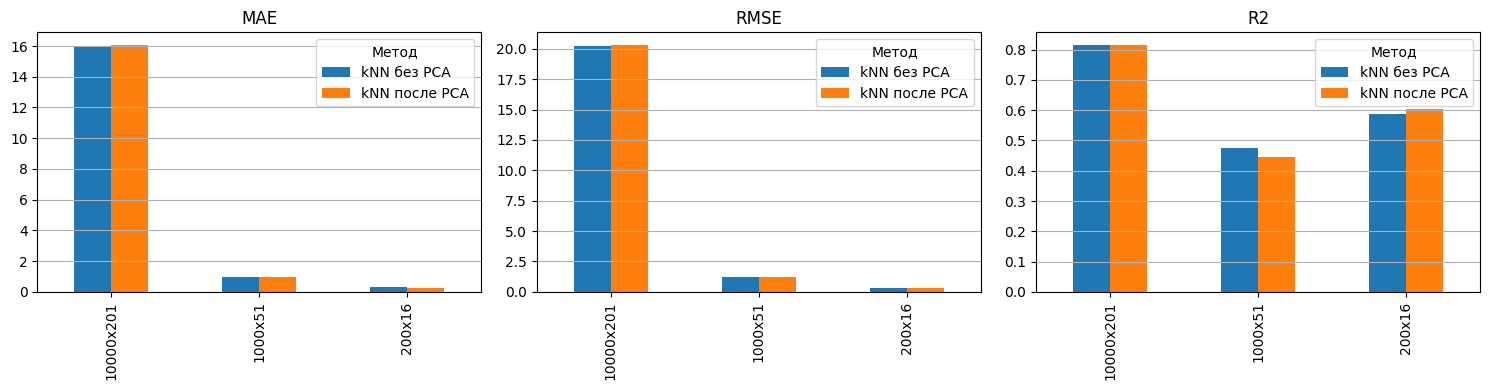

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    pivot = metrics_df.pivot(index='Набор данных', columns='Метод', values=metric)
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

## Визуализация первых двух главных компонент

Если оставить только первые две компоненты, можно посмотреть примерное расположение объектов на плоскости. Цветом обозначена целевая переменная `y`.

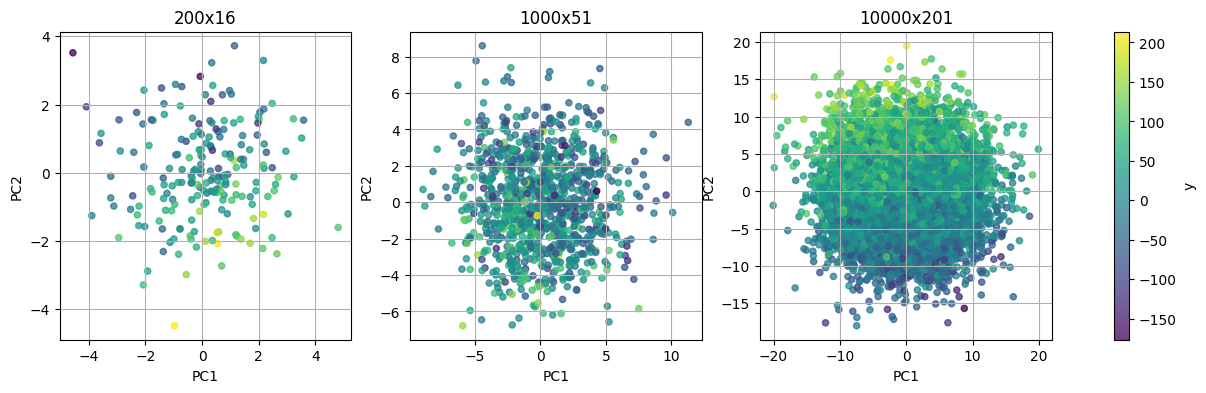

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, r in zip(axes, results):
    pca_df = r['pca_df']
    scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['y'], cmap='viridis', s=20, alpha=0.75)
    ax.set_title(r['name'])
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True)

fig.colorbar(scatter, ax=axes, label='y')
plt.show()

## Пример предсказаний

Посмотрим несколько фактических и предсказанных значений для первого набора данных.

In [12]:
first = results[0]
pred_examples = pd.DataFrame({
    'y_true': first['y_test'].values[:10],
    'pred_kNN_without_PCA': np.round(first['pred_base'][:10], 3),
    'pred_kNN_after_PCA': np.round(first['pred_pca'][:10], 3)
})
pred_examples

,y_true,pred_kNN_without_PCA,pred_kNN_after_PCA
0,0.93,1.476,1.476
1,2.03,1.732,1.732
2,1.93,1.552,1.552
3,0.94,1.258,1.258
4,1.22,1.242,1.362
5,0.53,1.066,0.640
6,2.44,2.136,2.334
7,1.49,1.692,1.584
8,1.29,1.098,1.240
9,1.78,1.278,1.278


## Вывод

В практической работе были загружены три синтетических набора данных разной размерности. Для каждого набора признаки были стандартизированы, после чего был применен метод главных компонент `PCA`.

Оптимальное количество компонент определялось по порогу 95% накопленной объясненной дисперсии. После этого главные компоненты были извлечены в новые датафреймы и сохранены в CSV-файлы.

В качестве метода машинного обучения был применен kNN, который использовался в предыдущих практических работах. Так как целевая переменная `y` является числовой, использован `KNeighborsRegressor`. Сравнение показало, как меняется качество модели при использовании исходных признаков и признаков после PCA. PCA уменьшает размерность данных и сохраняет основную часть информации, но итоговое качество зависит от того, насколько отброшенные компоненты важны для предсказания целевой переменной.